In [20]:
# ============================================================
# NOTEBOOK 03 — VIRTUAL SCREENING OF COCONUT AGAINST PfDHFR
# PfDHFR Inhibitor Discovery from African Natural Products
# ============================================================
# Target  : PfDHFR-TS K1 (PDB: 1J3I, CHEMBL1939)
# Input   : coconut_index.parquet (695,133 compounds)
#           best_classifier.pkl (Random Forest, ext AUC = 0.861)
#           best_regressor.pkl  (SVM, supplementary potency estimation)
#           ad_train_matrix.npy, ad_h_star.npy (applicability domain)
# Output  : vs_docking_shortlist.csv — top 200 candidates for Notebook 04
# ============================================================
# Screening Cascade
#   1. Lipinski drug-likeness filter  (pre-computed COCONUT descriptors)
#   2. ECFP4 generation + QSAR filter (p(active) >= 0.50)
#   3. Applicability domain flag      (leverage-based Williams plot)
#   4. NP-likeness filter             (np_likeness >= 0.0)
#   5. Tanimoto diversity filter      (remove Tc > 0.85 redundancy)
#   6. African NP prioritisation      (collections field contains "AfroDB")
#   7. Potency estimation             (SVM regressor, within-AD only)
#   8. Rank and shortlist             (top 200 for docking)
# ============================================================
 
 
# ── CELL 1: Imports & Configuration ──────────────────────────────────────────
 
import warnings
warnings.filterwarnings('ignore')
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import joblib
import gc
import time
 
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Descriptors
from rdkit.Chem import RDKFingerprint
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
 
from sklearn.decomposition import PCA
 
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_PROJ = Path(r"C:\my_projects_all\portfolio_projects\Msc_project")
DATA      = BASE_PROJ / "data"
MODELS    = BASE_PROJ / "models"
FIGURES   = BASE_PROJ / "figures"
 
for d in [MODELS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)
 
# ── Parameters ─────────────────────────────────────────────────────────────
SEED            = 42
BATCH_SIZE      = 10_000
QSAR_THRESHOLD  = 0.50
NP_LIKE_THRESH  = 0.0
TANIMOTO_CUTOFF = 0.85
TOP_N_DOCKING   = 200
 
np.random.seed(SEED)
 
print("✓ Imports complete")
print(f"  Data    : {DATA}")
print(f"  Models  : {MODELS}")
print(f"  Figures : {FIGURES}")
 

✓ Imports complete
  Data    : C:\my_projects_all\portfolio_projects\Msc_project\data
  Models  : C:\my_projects_all\portfolio_projects\Msc_project\models
  Figures : C:\my_projects_all\portfolio_projects\Msc_project\figures


In [21]:
# ── CELL 2: Load Assets ───────────────────────────────────────────────────────
 
print("\nLoading COCONUT index...")
coconut = pd.read_parquet(DATA / "coconut_index.parquet")
print(f"  COCONUT : {len(coconut):,} compounds, {coconut.shape[1]} columns")
 
REQUIRED_COLS = [
    'canonical_smiles', 'identifier', 'standard_inchi_key',
    'collections', 'np_likeness', 'np_classifier_pathway',
    'np_classifier_superclass', 'np_classifier_class',
    'qed_drug_likeliness', 'alogp', 'lipinski_rule_of_five_violations'
]
missing = [c for c in REQUIRED_COLS if c not in coconut.columns]
if missing:
    print(f"  ⚠ Missing columns: {missing}")
else:
    print("  ✓ All required columns present")
 
print("\nLoading trained models...")
clf = joblib.load(MODELS / "best_classifier.pkl")
reg = joblib.load(MODELS / "best_regressor.pkl")
print(f"  Classifier : {type(clf).__name__}")
print(f"  Regressor  : {type(reg).__name__}")
 
print("\nLoading AD parameters...")
ad_train_matrix = np.load(MODELS / "ad_train_matrix.npy")
ad_h_star       = float(np.load(MODELS / "ad_h_star.npy"))
XtX_inv         = np.linalg.pinv(ad_train_matrix.T @ ad_train_matrix)
print(f"  Training subsample shape : {ad_train_matrix.shape}")
print(f"  h* warning threshold     : {ad_h_star:.4f}")
 


Loading COCONUT index...
  COCONUT : 695,133 compounds, 34 columns
  ⚠ Missing columns: ['canonical_smiles', 'identifier', 'standard_inchi_key', 'np_likeness', 'np_classifier_pathway', 'np_classifier_superclass', 'np_classifier_class', 'qed_drug_likeliness', 'alogp', 'lipinski_rule_of_five_violations']

Loading trained models...
  Classifier : RandomForestClassifier
  Regressor  : Pipeline

Loading AD parameters...
  Training subsample shape : (500, 2048)
  h* warning threshold     : 12.2880


In [4]:
import pandas as pd
from pathlib import Path

coconut = pd.read_parquet(Path(r"C:\my_projects_all\portfolio_projects\Msc_project\data\coconut_index.parquet"))
print(list(coconut.columns))
print(coconut.head(2))

['coconut_id', 'smiles_coconut', 'inchikey_coconut', 'name_coconut', 'iupac_name_coconut', 'molecular_formula', 'mw_coconut', 'alogp_coconut', 'tpsa_coconut', 'hba_coconut', 'hbd_coconut', 'rot_bonds_coconut', 'qed_coconut', 'lipinski_violations', 'aromatic_rings', 'frac_csp3', 'np_likeness_score', 'np_pathway', 'np_superclass', 'np_class', 'chemical_class', 'chemical_superclass', 'direct_parent', 'coconut_organisms', 'collections', 'contains_sugar', 'contains_ring_sugars', 'dois', 'source_database', 'is_african_np', 'lipinski_pass', 'inchikey_14', 'npass_np_id', 'in_npass']
     coconut_id                                     smiles_coconut  \
0  CNP0282693.1  COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...   
1  CNP0214016.1  COc1cc2cc(c1Cl)N(C)C(=O)C[C@H](OC(=O)[C@H](C)N...   

              inchikey_coconut name_coconut  \
0  ITSGNOIFAJAQHJ-BMFNZSJVSA-N   Esorubicin   
1  WKPWGQKGSOKKOO-RSFHAFMBSA-N   MAYTANSINE   

                                  iupac_name_coconut molecular_fo

In [22]:
# ── CELL 2b: Harmonise COCONUT Column Names ───────────────────────────────────
# Rename parquet columns to the names expected throughout this notebook.
# is_african_np and lipinski_pass are already pre-computed — no derivation needed.

COCONUT_COL_MAP = {
    'coconut_id'        : 'identifier',
    'smiles_coconut'    : 'canonical_smiles',
    'inchikey_coconut'  : 'standard_inchi_key',
    'alogp_coconut'     : 'alogp',
    'qed_coconut'       : 'qed_drug_likeliness',
    'np_likeness_score' : 'np_likeness',
    'np_pathway'        : 'np_classifier_pathway',
    'np_superclass'     : 'np_classifier_superclass',
    'np_class'          : 'np_classifier_class',
    'coconut_organisms' : 'organisms',
    # lipinski_violations already named correctly — no rename needed
}
coconut.rename(columns=COCONUT_COL_MAP, inplace=True)

# Verify all expected columns now present
REQUIRED_COLS = [
    'canonical_smiles', 'identifier', 'standard_inchi_key',
    'collections', 'np_likeness', 'np_classifier_pathway',
    'np_classifier_superclass', 'np_classifier_class',
    'qed_drug_likeliness', 'alogp', 'lipinski_violations',
    'is_african_np', 'lipinski_pass'
]
missing = [c for c in REQUIRED_COLS if c not in coconut.columns]
if missing:
    print(f"  ⚠ Still missing: {missing}")
else:
    print("  ✓ All columns mapped successfully")

print(f"  is_african_np pre-computed  : {coconut['is_african_np'].sum():,} African NPs")
print(f"  lipinski_pass pre-computed  : {coconut['lipinski_pass'].sum():,} Lipinski-passing")

  ✓ All columns mapped successfully
  is_african_np pre-computed  : 901 African NPs
  lipinski_pass pre-computed  : 477,975 Lipinski-passing


In [23]:
# ── CELL 3: Helper Functions ──────────────────────────────────────────────────
 
def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    """
    Convert list of SMILES to (n x n_bits) uint8 numpy array of Morgan (ECFP4) fps.
    Uses MorganGenerator API (RDKit >= 2024.03). Invalid SMILES → zero vector.
    Returns fp_array and valid_mask.
    """
    generator = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps   = np.zeros((len(smiles_list), n_bits), dtype=np.uint8)
    valid = np.ones(len(smiles_list), dtype=bool)
    for i, smi in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(str(smi))
            if mol is not None:
                DataStructs.ConvertToNumpyArray(
                    generator.GetFingerprint(mol), fps[i]
                )
            else:
                valid[i] = False
        except Exception:
            valid[i] = False
    return fps, valid
 
 
def smiles_to_rdkit_fp(smiles_list, n_bits=2048):
    """RDKit topological fingerprints — secondary descriptor for regressor."""
    fps   = np.zeros((len(smiles_list), n_bits), dtype=np.uint8)
    valid = np.ones(len(smiles_list), dtype=bool)
    for i, smi in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(str(smi))
            if mol is not None:
                DataStructs.ConvertToNumpyArray(
                    RDKFingerprint(mol, fpSize=n_bits), fps[i]
                )
            else:
                valid[i] = False
        except Exception:
            valid[i] = False
    return fps, valid
 
 
def compute_physchem(smiles_list):
    """
    Compute 8 physicochemical descriptors for a list of SMILES.
    Returns float64 array (n x 8): MW, LogP, TPSA, HBD, HBA, RotBonds, RingCount, AromaticRings.
    NaN for failed molecules.
    """
    phys = np.full((len(smiles_list), 8), np.nan, dtype=np.float64)
    for i, smi in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(str(smi))
            if mol is not None:
                phys[i] = [
                    Descriptors.MolWt(mol),
                    Descriptors.MolLogP(mol),
                    Descriptors.TPSA(mol),
                    Descriptors.NumHDonors(mol),
                    Descriptors.NumHAcceptors(mol),
                    Descriptors.NumRotatableBonds(mol),
                    Descriptors.RingCount(mol),
                    Descriptors.NumAromaticRings(mol),
                ]
        except Exception:
            pass
    return phys
 
 
def compute_leverage(XtX_inv_mat, X_query):
    """
    Compute leverage h_i = x_i^T (X^T X)^{-1} x_i for each row of X_query.
    XtX_inv_mat : pre-computed pseudo-inverse, shape (p, p).
    """
    X_q = X_query.astype(np.float64)
    return np.array([float(x @ XtX_inv_mat @ x) for x in X_q])
 
 
def is_african_np(collections_val):
    """Return True if 'AfroDB' appears in the COCONUT collections field."""
    if pd.isna(collections_val):
        return False
    if isinstance(collections_val, list):
        return any("AfroDB" in str(c) for c in collections_val)
    return "AfroDB" in str(collections_val)
 
 
print("✓ Helper functions defined")
 

✓ Helper functions defined


In [24]:
# ── CELL 4: Stage 1 — Lipinski Drug-Likeness Filter ──────────────────────────
# lipinski_pass is pre-computed in coconut_index.parquet — use directly.
# No RDKit recomputation needed.

print("\n" + "=" * 60)
print("STAGE 1 — LIPINSKI DRUG-LIKENESS FILTER")
print("=" * 60)

n_start = len(coconut)

coconut_lip = coconut[coconut['lipinski_pass'] == True].copy()
n_after_lip = len(coconut_lip)

print(f"  Input    : {n_start:,}")
print(f"  Output   : {n_after_lip:,} ({100*n_after_lip/n_start:.1f}% retained)")
print(f"  Removed  : {n_start - n_after_lip:,}")

del coconut
gc.collect()


STAGE 1 — LIPINSKI DRUG-LIKENESS FILTER
  Input    : 695,133
  Output   : 477,975 (68.8% retained)
  Removed  : 217,158


536

In [25]:
# ── CELL 5: Stage 2 — ECFP4 Generation & QSAR Filter ────────────────────────
# Generate Morgan fingerprints (radius=2, nBits=2048) in batches of 10,000.
# Apply best_classifier.predict_proba to each batch.
# Retain compounds with p(active) >= 0.50.
 
print("\n" + "=" * 60)
print("STAGE 2 — ECFP4 + QSAR FILTER")
print("=" * 60)
print(f"  Input           : {n_after_lip:,}")
print(f"  Batch size      : {BATCH_SIZE:,}")
print(f"  QSAR threshold  : p >= {QSAR_THRESHOLD}")
 
smiles_arr = coconut_lip['canonical_smiles'].values
n_total    = len(smiles_arr)
n_batches  = int(np.ceil(n_total / BATCH_SIZE))
 
all_probs        = np.full(n_total, np.nan)
all_valid_smiles = np.ones(n_total, dtype=bool)
 
t0 = time.time()
for b in range(n_batches):
    start        = b * BATCH_SIZE
    end          = min(start + BATCH_SIZE, n_total)
    batch_smiles = smiles_arr[start:end]
 
    fps, valid = smiles_to_morgan(batch_smiles)
    all_valid_smiles[start:end] = valid
 
    probs             = clf.predict_proba(fps)[:, 1]
    probs[~valid]     = np.nan
    all_probs[start:end] = probs
 
    elapsed = time.time() - t0
    rate    = end / elapsed if elapsed > 0 else 1
    eta     = (n_total - end) / rate if rate > 0 else 0
    print(f"  Batch {b+1:3d}/{n_batches} | {end:7,}/{n_total:,} | "
          f"{elapsed:.0f}s elapsed | ETA {eta:.0f}s", end='\r')
 
    del fps
    gc.collect()
 
print(f"\n  Completed in {time.time()-t0:.1f}s")
 
coconut_lip['p_active']     = all_probs
coconut_lip['valid_smiles'] = all_valid_smiles
 
n_invalid    = (~all_valid_smiles).sum()
qsar_mask    = (coconut_lip['p_active'] >= QSAR_THRESHOLD) & coconut_lip['valid_smiles']
coconut_qsar = coconut_lip[qsar_mask].copy()
n_after_qsar = len(coconut_qsar)
 
print(f"  Invalid SMILES  : {n_invalid:,}")
print(f"  QSAR hits       : {n_after_qsar:,} ({100*n_after_qsar/n_after_lip:.2f}%)")
print(f"  Mean p(active)  : {coconut_qsar['p_active'].mean():.3f}")
 
# Save full probability array for Figure 6
np.save(DATA / "screening_probs_all.npy",
        all_probs[all_valid_smiles & ~np.isnan(all_probs)])

# Checkpoint — save QSAR hits so kernel restart doesn't require rerunning batch
coconut_qsar.to_parquet(DATA / "vs_checkpoint_qsar_hits.parquet", index=False)
print(f"  Checkpoint saved: vs_checkpoint_qsar_hits.parquet")
  
del coconut_lip
gc.collect()



STAGE 2 — ECFP4 + QSAR FILTER
  Input           : 477,975
  Batch size      : 10,000
  QSAR threshold  : p >= 0.5


[08:25:56] WARNING: not removing hydrogen atom without neighbors


[08:27:44] WARNING: not removing hydrogen atom without neighbors


[08:27:59] WARNING: not removing hydrogen atom without neighbors
[08:27:59] WARNING: not removing hydrogen atom without neighbors


[08:28:11] Unusual charge on atom 37 number of radical electrons set to zero


[08:28:40] WARNING: not removing hydrogen atom without neighbors


  Batch  48/48 | 477,975/477,975 | 562s elapsed | ETA 0sss
  Completed in 561.9s
  Invalid SMILES  : 0
  QSAR hits       : 2,072 (0.43%)
  Mean p(active)  : 0.536
  Checkpoint saved: vs_checkpoint_qsar_hits.parquet


0

In [26]:
# ── RECOVERY: Reconstruct coconut_qsar from saved probability array ───────────
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path(r"C:\my_projects_all\portfolio_projects\Msc_project\data")

# Reload the Lipinski-filtered set and reattach probabilities
coconut = pd.read_parquet(DATA / "coconut_index.parquet")

COCONUT_COL_MAP = {
    'coconut_id'        : 'identifier',
    'smiles_coconut'    : 'canonical_smiles',
    'inchikey_coconut'  : 'standard_inchi_key',
    'alogp_coconut'     : 'alogp',
    'qed_coconut'       : 'qed_drug_likeliness',
    'np_likeness_score' : 'np_likeness',
    'np_pathway'        : 'np_classifier_pathway',
    'np_superclass'     : 'np_classifier_superclass',
    'np_class'          : 'np_classifier_class',
    'coconut_organisms' : 'organisms',
}
coconut.rename(columns=COCONUT_COL_MAP, inplace=True)

coconut_lip = coconut[coconut['lipinski_pass'] == True].copy()
n_after_lip = len(coconut_lip)

# Reload saved probabilities and reattach
probs_all = np.load(DATA / "screening_probs_all.npy")  # valid-only probs

# Reconstruct full-length prob array (lipinski set, valid_smiles all True per Cell 5)
coconut_lip['p_active']     = probs_all          # 477,975 values, same order
coconut_lip['valid_smiles'] = True

QSAR_THRESHOLD = 0.50
qsar_mask    = coconut_lip['p_active'] >= QSAR_THRESHOLD
coconut_qsar = coconut_lip[qsar_mask].copy()
n_after_qsar = len(coconut_qsar)

print(f"  Lipinski set restored : {n_after_lip:,}")
print(f"  QSAR hits restored    : {n_after_qsar:,}")
print(f"  Mean p(active)        : {coconut_qsar['p_active'].mean():.3f}")

del coconut, coconut_lip
import gc; gc.collect()

  Lipinski set restored : 477,975
  QSAR hits restored    : 2,072
  Mean p(active)        : 0.536


11

In [ ]:
# ── CELL 6: Stage 3 — Applicability Domain Flag ──────────────────────────────
# Compute leverage h_i for all QSAR hits using pre-computed XtX_inv.
# Flag outside-AD compounds (h >= h*) but do NOT discard — report separately.
# Consistent with Notebook 02 AD framework and OECD guidance.
 
print("\n" + "=" * 60)
print("STAGE 3 — APPLICABILITY DOMAIN FLAG")
print("=" * 60)
print(f"  Input    : {n_after_qsar:,} QSAR hits")
print(f"  h*       : {ad_h_star:.4f}")
 
smiles_qsar = coconut_qsar['canonical_smiles'].values
n_qsar      = len(smiles_qsar)
leverages   = np.zeros(n_qsar, dtype=np.float64)
 
t0 = time.time()
for b in range(int(np.ceil(n_qsar / BATCH_SIZE))):
    start = b * BATCH_SIZE
    end   = min(start + BATCH_SIZE, n_qsar)
    fps, _ = smiles_to_morgan(smiles_qsar[start:end])
    leverages[start:end] = compute_leverage(XtX_inv, fps)
    del fps
    gc.collect()
    print(f"  AD batch {b+1} | {end:,}/{n_qsar:,}", end='\r')
 
print(f"\n  Completed in {time.time()-t0:.1f}s")
 
coconut_qsar['leverage']  = leverages
coconut_qsar['within_ad'] = leverages < ad_h_star
 
n_within_ad  = int(coconut_qsar['within_ad'].sum())
n_outside_ad = n_after_qsar - n_within_ad
print(f"  Within AD   : {n_within_ad:,} ({100*n_within_ad/n_after_qsar:.1f}%)")
print(f"  Outside AD  : {n_outside_ad:,} — flagged, not discarded")
coconut_qsar.to_parquet(DATA / "vs_checkpoint_post_ad.parquet", index=False)
print("  Checkpoint saved: vs_checkpoint_post_ad.parquet")
 
 


STAGE 3 — APPLICABILITY DOMAIN FLAG
  Input    : 2,072 QSAR hits
  h*       : 12.2880
  AD batch 1 | 2,072/2,072
  Completed in 7.7s
  Within AD   : 718 (34.7%)
  Outside AD  : 1,354 — flagged, not discarded


In [28]:
print(coconut_qsar['within_ad'].value_counts())
print(f"\nOutside-AD hits p(active) distribution:")
print(coconut_qsar[~coconut_qsar['within_ad']]['p_active'].describe().round(3))
print(f"\nWithin-AD hits p(active) distribution:")
print(coconut_qsar[coconut_qsar['within_ad']]['p_active'].describe().round(3))

within_ad
False    1354
True      718
Name: count, dtype: int64

Outside-AD hits p(active) distribution:
count    1354.000
mean        0.528
std         0.030
min         0.500
25%         0.508
50%         0.519
75%         0.540
max         0.821
Name: p_active, dtype: float64

Within-AD hits p(active) distribution:
count    718.000
mean       0.551
std        0.076
min        0.500
25%        0.510
50%        0.525
75%        0.552
max        0.973
Name: p_active, dtype: float64


In [29]:
for thresh in [0.50, 0.55, 0.60, 0.65, 0.70]:
    n_in  = (coconut_qsar[coconut_qsar['within_ad']]['p_active'] >= thresh).sum()
    n_out = (coconut_qsar[~coconut_qsar['within_ad']]['p_active'] >= thresh).sum()
    print(f"  p >= {thresh} | within-AD: {n_in:4d} | outside-AD: {n_out:4d} | total: {n_in+n_out:4d}")

  p >= 0.5 | within-AD:  718 | outside-AD: 1354 | total: 2072
  p >= 0.55 | within-AD:  190 | outside-AD:  230 | total:  420
  p >= 0.6 | within-AD:   91 | outside-AD:   30 | total:  121
  p >= 0.65 | within-AD:   57 | outside-AD:    5 | total:   62
  p >= 0.7 | within-AD:   42 | outside-AD:    4 | total:   46


In [30]:
# Apply tiered threshold
QSAR_THRESH_WITHIN  = 0.50
QSAR_THRESH_OUTSIDE = 0.60

mask_tiered = (
    (coconut_qsar['within_ad'] & (coconut_qsar['p_active'] >= QSAR_THRESH_WITHIN)) |
    (~coconut_qsar['within_ad'] & (coconut_qsar['p_active'] >= QSAR_THRESH_OUTSIDE))
)
coconut_qsar = coconut_qsar[mask_tiered].copy()
n_after_qsar = len(coconut_qsar)

print(f"  After tiered threshold filter : {n_after_qsar:,}")
print(f"    Within-AD  (p >= {QSAR_THRESH_WITHIN})  : {coconut_qsar['within_ad'].sum():,}")
print(f"    Outside-AD (p >= {QSAR_THRESH_OUTSIDE}) : {(~coconut_qsar['within_ad']).sum():,}")

  After tiered threshold filter : 748
    Within-AD  (p >= 0.5)  : 718
    Outside-AD (p >= 0.6) : 30


In [31]:
# ── CELL 7: Stage 4 — NP-Likeness Filter ─────────────────────────────────────
# Retain compounds with np_likeness >= 0.
# Removes synthetic-like molecules that entered COCONUT without NP character.
 
print("\n" + "=" * 60)
print("STAGE 4 — NP-LIKENESS FILTER")
print("=" * 60)
 
coconut_qsar['np_likeness_num'] = pd.to_numeric(
    coconut_qsar['np_likeness'], errors='coerce'
).fillna(-999)
 
npl_mask    = coconut_qsar['np_likeness_num'] >= NP_LIKE_THRESH
coconut_npl = coconut_qsar[npl_mask].copy()
n_after_npl = len(coconut_npl)
 
print(f"  Input    : {n_after_qsar:,}")
print(f"  Output   : {n_after_npl:,} (np_likeness >= {NP_LIKE_THRESH})")
print(f"  Removed  : {n_after_qsar - n_after_npl:,}")
 
del coconut_qsar
gc.collect()
 
 


STAGE 4 — NP-LIKENESS FILTER
  Input    : 748
  Output   : 219 (np_likeness >= 0.0)
  Removed  : 529


0

In [33]:
# ── RECOVERY: Reconstruct coconut_qsar with tiered threshold applied ──────────
import pandas as pd
import numpy as np
from pathlib import Path
import gc

DATA = Path(r"C:\my_projects_all\portfolio_projects\Msc_project\data")

coconut_qsar = pd.read_parquet(DATA / "vs_checkpoint_qsar_hits.parquet")

# Reattach AD flags — recompute leverage
import joblib
MODELS = Path(r"C:\my_projects_all\portfolio_projects\Msc_project\models")
ad_train_matrix = np.load(MODELS / "ad_train_matrix.npy")
ad_h_star       = float(np.load(MODELS / "ad_h_star.npy"))
XtX_inv         = np.linalg.pinv(ad_train_matrix.T @ ad_train_matrix)

# Check if leverage already in checkpoint
if 'leverage' not in coconut_qsar.columns:
    print("Recomputing leverage...")
    from rdkit import Chem
    from rdkit.Chem import AllChem, DataStructs
    
    def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
        generator = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
        fps   = np.zeros((len(smiles_list), n_bits), dtype=np.uint8)
        valid = np.ones(len(smiles_list), dtype=bool)
        for i, smi in enumerate(smiles_list):
            try:
                mol = Chem.MolFromSmiles(str(smi))
                if mol is not None:
                    DataStructs.ConvertToNumpyArray(generator.GetFingerprint(mol), fps[i])
                else:
                    valid[i] = False
            except Exception:
                valid[i] = False
        return fps, valid

    fps, _ = smiles_to_morgan(coconut_qsar['canonical_smiles'].values)
    leverages = np.array([float(x @ XtX_inv @ x) for x in fps.astype(np.float64)])
    coconut_qsar['leverage']  = leverages
    coconut_qsar['within_ad'] = leverages < ad_h_star
else:
    print("Leverage already in checkpoint ✓")

# Reapply tiered threshold
QSAR_THRESH_WITHIN  = 0.50
QSAR_THRESH_OUTSIDE = 0.60
mask_tiered = (
    (coconut_qsar['within_ad'] & (coconut_qsar['p_active'] >= QSAR_THRESH_WITHIN)) |
    (~coconut_qsar['within_ad'] & (coconut_qsar['p_active'] >= QSAR_THRESH_OUTSIDE))
)
coconut_qsar = coconut_qsar[mask_tiered].copy()
n_after_qsar = len(coconut_qsar)

print(f"  coconut_qsar restored : {n_after_qsar:,} compounds")
print(f"  Within-AD             : {coconut_qsar['within_ad'].sum():,}")
print(f"  Outside-AD            : {(~coconut_qsar['within_ad']).sum():,}")

Recomputing leverage...
  coconut_qsar restored : 748 compounds
  Within-AD             : 718
  Outside-AD            : 30


In [34]:
print("NP-likeness distribution — all QSAR hits:")
coconut_qsar['np_likeness_num'] = pd.to_numeric(
    coconut_qsar['np_likeness'], errors='coerce'
).fillna(-999)

print(coconut_qsar['np_likeness_num'].describe().round(3))
print(f"\n  NaN count : {coconut_qsar['np_likeness'].isna().sum()}")
print(f"  Negative  : {(coconut_qsar['np_likeness_num'] < 0).sum()}")
print(f"  Zero      : {(coconut_qsar['np_likeness_num'] == 0).sum()}")
print(f"  Positive  : {(coconut_qsar['np_likeness_num'] > 0).sum()}")

bins   = [-999, -2, -1, 0, 1, 2, 3, 999]
labels = ['< -2', '-2 to -1', '-1 to 0', '0 to 1', '1 to 2', '2 to 3', '> 3']
print("\nScore breakdown:")
print(pd.cut(coconut_qsar['np_likeness_num'], bins=bins, labels=labels).value_counts().sort_index())

NP-likeness distribution — all QSAR hits:
count    748.000
mean      -0.276
std        0.794
min       -2.000
25%       -0.790
50%       -0.340
75%        0.100
max        2.910
Name: np_likeness_num, dtype: float64

  NaN count : 0
  Negative  : 529
  Zero      : 3
  Positive  : 216

Score breakdown:
np_likeness_num
< -2          1
-2 to -1    115
-1 to 0     416
0 to 1      171
1 to 2       28
2 to 3       17
> 3           0
Name: count, dtype: int64


In [35]:
# ── CELL 8: Stage 5 — Tanimoto Diversity Filter ──────────────────────────────
# Greedy leader-picking: compounds sorted by p(active) descending.
# A compound is retained only if its maximum Tanimoto similarity to all
# existing cluster leaders is < TANIMOTO_CUTOFF.
# Ensures structural diversity in the downstream docking set.

print("\n" + "=" * 60)
print("STAGE 5 — TANIMOTO DIVERSITY FILTER")
print("=" * 60)
print(f"  Input              : {n_after_npl:,}")
print(f"  Similarity cutoff  : Tc < {TANIMOTO_CUTOFF}")

smiles_npl = coconut_npl['canonical_smiles'].values
probs_npl  = coconut_npl['p_active'].values
order      = np.argsort(-probs_npl)   # descending p(active)

print("  Computing fingerprints for diversity filter...")
generator      = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fps_rdkit_objs = []
valid_idx      = []
for idx in order:
    mol = Chem.MolFromSmiles(str(smiles_npl[idx]))
    if mol is not None:
        fps_rdkit_objs.append(generator.GetFingerprint(mol))
        valid_idx.append(idx)

kept_mask  = np.zeros(len(smiles_npl), dtype=bool)
leader_fps = []

t0 = time.time()
for i, (fp, orig_idx) in enumerate(zip(fps_rdkit_objs, valid_idx)):
    if not leader_fps or max(DataStructs.BulkTanimotoSimilarity(fp, leader_fps)) < TANIMOTO_CUTOFF:
        leader_fps.append(fp)
        kept_mask[orig_idx] = True
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1:,}/{len(fps_rdkit_objs):,} | "
              f"Clusters: {kept_mask.sum():,}", end='\r')

print(f"\n  Completed in {time.time()-t0:.1f}s")

coconut_div  = coconut_npl[kept_mask].copy()
n_after_div  = len(coconut_div)
print(f"  Output   : {n_after_div:,} diverse representatives")
print(f"  Removed  : {n_after_npl - n_after_div:,} redundant compounds")

del coconut_npl, fps_rdkit_objs
gc.collect()


STAGE 5 — TANIMOTO DIVERSITY FILTER
  Input              : 219
  Similarity cutoff  : Tc < 0.85
  Computing fingerprints for diversity filter...

  Completed in 0.0s
  Output   : 143 diverse representatives
  Removed  : 76 redundant compounds


1046

In [36]:
# ── CELL 9: Stage 6 — African NP Prioritisation ──────────────────────────────
# is_african_np is pre-computed in coconut_index.parquet — use directly.

print("\n" + "=" * 60)
print("STAGE 6 — AFRICAN NP PRIORITISATION")
print("=" * 60)

# Ensure boolean type (parquet may load as object)
coconut_div['is_african_np'] = coconut_div['is_african_np'].astype(bool)

african_hits = coconut_div[coconut_div['is_african_np']].copy()
global_hits  = coconut_div[~coconut_div['is_african_np']].copy()

print(f"  Total diverse hits        : {n_after_div:,}")
print(f"  African NP tier (AfroDB)  : {len(african_hits):,}")
print(f"  Global NP tier            : {len(global_hits):,}")
print(f"  African NP within AD      : {african_hits['within_ad'].sum():,} "
      f"({100*african_hits['within_ad'].mean():.1f}%)")


STAGE 6 — AFRICAN NP PRIORITISATION
  Total diverse hits        : 143
  African NP tier (AfroDB)  : 0
  Global NP tier            : 143
  African NP within AD      : 0 (nan%)


In [37]:
# Diagnose African NP flag in the 143 diverse hits
print("is_african_np value counts:")
print(coconut_div['is_african_np'].value_counts(dropna=False))
print(f"\nDtype: {coconut_div['is_african_np'].dtype}")

# Check the collections field directly
print("\nSample collections values:")
print(coconut_div['collections'].head(10).tolist())

# Check if AfroDB appears anywhere in collections
afrodb_in_collections = coconut_div['collections'].astype(str).str.contains('AfroDB', na=False)
print(f"\nCompounds with 'AfroDB' in collections string: {afrodb_in_collections.sum()}")

# Check original COCONUT parquet before any filtering
import pandas as pd
from pathlib import Path
DATA = Path(r"C:\my_projects_all\portfolio_projects\Msc_project\data")
coconut_full = pd.read_parquet(DATA / "coconut_index.parquet")
print(f"\nIn full COCONUT parquet:")
print(f"  is_african_np == True  : {(coconut_full['is_african_np'] == True).sum():,}")
print(f"  is_african_np == False : {(coconut_full['is_african_np'] == False).sum():,}")
print(f"  AfroDB in collections  : {coconut_full['collections'].astype(str).str.contains('AfroDB', na=False).sum():,}")

is_african_np value counts:
is_african_np
False    143
Name: count, dtype: int64

Dtype: bool

Sample collections values:
['ChEMBL NPs', 'GNPS (Global Natural Products Social Molecular Networking)|Supernatural3', 'GNPS (Global Natural Products Social Molecular Networking)', 'GNPS (Global Natural Products Social Molecular Networking)', 'GNPS (Global Natural Products Social Molecular Networking)', 'FooDB|GNPS (Global Natural Products Social Molecular Networking)', 'FooDB|GNPS (Global Natural Products Social Molecular Networking)', 'GNPS (Global Natural Products Social Molecular Networking)', 'GNPS (Global Natural Products Social Molecular Networking)|Supernatural3', 'Australian natural products|CMAUP (cCollective molecular activities of useful plants)|ChEBI NPs|DrugBankNP|Exposome-explorer|FooDB|GNPS (Global Natural Products Social Molecular Networking)|InterBioScreen Ltd|NPASS|NPEdia|Phyto4Health|Super Natural II']

Compounds with 'AfroDB' in collections string: 0

In full COCONUT parqu

In [40]:
# Trace African NP attrition using available checkpoint
qsar_checkpoint = pd.read_parquet(DATA / "vs_checkpoint_qsar_hits.parquet")
print(f"Columns in QSAR checkpoint: {list(qsar_checkpoint.columns)}\n")

# How many African NPs made it to the QSAR stage (p >= 0.50)
african_qsar = qsar_checkpoint[qsar_checkpoint['is_african_np'] == True]
print(f"Stage 2 — After QSAR (p >= 0.50)          : {len(african_qsar):,}")

if len(african_qsar) == 0:
    # Lost at QSAR — check their probabilities by running RF on them now
    print("No African NPs reached p >= 0.50 — checking their probability distribution...")
    
    african_lip = coconut_full[
        (coconut_full['is_african_np'] == True) & 
        (coconut_full['lipinski_pass'] == True)
    ].copy()
    print(f"African NPs entering QSAR screen : {len(african_lip):,}")
    
    from rdkit import Chem
    from rdkit.Chem import AllChem, DataStructs
    import joblib
    
    clf = joblib.load(MODELS / "best_classifier.pkl")
    generator = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
    
    fps = np.zeros((len(african_lip), 2048), dtype=np.uint8)
    for i, smi in enumerate(african_lip['smiles_coconut'].values):
        try:
            mol = Chem.MolFromSmiles(str(smi))
            if mol is not None:
                DataStructs.ConvertToNumpyArray(generator.GetFingerprint(mol), fps[i])
        except Exception:
            pass
    
    probs = clf.predict_proba(fps)[:, 1]
    african_lip['p_active'] = probs
    
    print(f"\nAfrican NP p(active) distribution (all 767 Lipinski-passing):")
    print(african_lip['p_active'].describe().round(3))
    print(f"\nAt different thresholds:")
    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        print(f"  p >= {t} : {(probs >= t).sum():,}")
else:
    print(f"\np(active) distribution of African NP QSAR hits:")
    print(african_qsar['p_active'].describe().round(3))

Columns in QSAR checkpoint: ['identifier', 'canonical_smiles', 'standard_inchi_key', 'name_coconut', 'iupac_name_coconut', 'molecular_formula', 'mw_coconut', 'alogp', 'tpsa_coconut', 'hba_coconut', 'hbd_coconut', 'rot_bonds_coconut', 'qed_drug_likeliness', 'lipinski_violations', 'aromatic_rings', 'frac_csp3', 'np_likeness', 'np_classifier_pathway', 'np_classifier_superclass', 'np_classifier_class', 'chemical_class', 'chemical_superclass', 'direct_parent', 'organisms', 'collections', 'contains_sugar', 'contains_ring_sugars', 'dois', 'source_database', 'is_african_np', 'lipinski_pass', 'inchikey_14', 'npass_np_id', 'in_npass', 'p_active', 'valid_smiles']

Stage 2 — After QSAR (p >= 0.50)          : 0
No African NPs reached p >= 0.50 — checking their probability distribution...
African NPs entering QSAR screen : 767

African NP p(active) distribution (all 767 Lipinski-passing):
count    767.000
mean       0.257
std        0.064
min        0.094
25%        0.212
50%        0.254
75%       

In [44]:
print("Top 20 African NPs by p(active):")

print(african_lip[['coconut_id', 'smiles_coconut', 'p_active',
                   'np_likeness_score', 'np_pathway', 'coconut_organisms']]
      .sort_values('p_active', ascending=False)
      .head(20)
      .to_string(index=False))

print(f"\nNP-likeness distribution of top 173 (p >= 0.30):")
top_african = african_lip[african_lip['p_active'] >= 0.30].copy()
top_african['np_likeness_num'] = pd.to_numeric(top_african['np_likeness_score'], errors='coerce')
print(top_african['np_likeness_num'].describe().round(3))
print(f"\nNP-likeness >= 0 among top 173: {(top_african['np_likeness_num'] >= 0).sum()}")

Top 20 African NPs by p(active):
   coconut_id                                                                                                                    smiles_coconut  p_active  np_likeness_score                      np_pathway                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [47]:
# ── Build African NP tier with relaxed threshold ──────────────────────────────

AFRICAN_QSAR_THRESH = 0.30
NP_LIKE_THRESH      = 0.0
TANIMOTO_CUTOFF     = 0.85

# Filter and annotate
top_african = african_lip[african_lip['p_active'] >= AFRICAN_QSAR_THRESH].copy()
top_african['np_likeness_num'] = pd.to_numeric(
    top_african['np_likeness_score'], errors='coerce').fillna(-999)

# Remove silicon-containing compounds (artefacts)
top_african = top_african[~top_african['smiles_coconut'].str.contains(r'\[Si\]', regex=True)]

# NP-likeness filter
top_african = top_african[top_african['np_likeness_num'] >= NP_LIKE_THRESH].copy()
print(f"African NPs after p >= 0.30 + NP-likeness filter : {len(top_african):,}")

# Tanimoto diversity filter
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

top_african = top_african.sort_values('p_active', ascending=False).reset_index(drop=True)
generator   = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

fps_objs  = []
valid_idx = []
for i, smi in enumerate(top_african['smiles_coconut'].values):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        fps_objs.append(generator.GetFingerprint(mol))
        valid_idx.append(i)

kept_mask  = np.zeros(len(top_african), dtype=bool)
leader_fps = []
for fp, idx in zip(fps_objs, valid_idx):
    if not leader_fps or max(DataStructs.BulkTanimotoSimilarity(fp, leader_fps)) < TANIMOTO_CUTOFF:
        leader_fps.append(fp)
        kept_mask[idx] = True

african_diverse = top_african[kept_mask].copy().reset_index(drop=True)
african_diverse['african_rank'] = np.arange(1, len(african_diverse) + 1)
african_diverse['is_african_np'] = True
print(f"African NPs after diversity filter               : {len(african_diverse):,}")

# Drop pre-existing np_likeness_num before rename to avoid duplicate
african_diverse = african_diverse.drop(columns=['np_likeness_num'], errors='ignore')

# ── Rename columns to match global hits (coconut_div) ────────────────────────
african_diverse = african_diverse.rename(columns={
    'coconut_id'        : 'identifier',
    'smiles_coconut'    : 'canonical_smiles',
    'inchikey_coconut'  : 'standard_inchi_key',
    'np_likeness_score' : 'np_likeness_num',
    'np_pathway'        : 'np_classifier_pathway',
    'np_superclass'     : 'np_classifier_superclass',
    'np_class'          : 'np_classifier_class',
    'coconut_organisms' : 'organisms',
    'alogp_coconut'     : 'alogp',
    'qed_coconut'       : 'qed_drug_likeliness',
})

# ── Combine with global NP diverse hits ──────────────────────────────────────
# coconut_div already contains 143 global diverse hits from Stage 5
combined = pd.concat([african_diverse, coconut_div], ignore_index=True)
combined = combined.sort_values('p_active', ascending=False).reset_index(drop=True)
combined['docking_rank'] = np.arange(1, len(combined) + 1)

print(f"\nCombined docking set                             : {len(combined):,}")
print(f"  African NP tier (p >= 0.30)                  : {combined['is_african_np'].sum():,}")
print(f"  Global NP tier  (p >= 0.50)                  : {(~combined['is_african_np']).sum():,}")
print(f"  p(active) range : [{combined['p_active'].min():.3f}, {combined['p_active'].max():.3f}]")

# Save
combined.to_csv(DATA / "vs_docking_shortlist.csv", index=False)
combined[['identifier', 'canonical_smiles', 'p_active',
          'is_african_np', 'docking_rank']].to_csv(DATA / "vs_docking_smiles.csv", index=False)
african_diverse.to_csv(DATA / "vs_african_np_hits.csv", index=False)

print(f"\n✓ Saved vs_docking_shortlist.csv — {len(combined):,} compounds")
print(f"✓ Saved vs_docking_smiles.csv")
print(f"✓ Saved vs_african_np_hits.csv — {len(african_diverse):,} African NPs")

African NPs after p >= 0.30 + NP-likeness filter : 168
African NPs after diversity filter               : 159

Combined docking set                             : 302
  African NP tier (p >= 0.30)                  : 159
  Global NP tier  (p >= 0.50)                  : 143
  p(active) range : [0.300, 0.747]

✓ Saved vs_docking_shortlist.csv — 302 compounds
✓ Saved vs_docking_smiles.csv
✓ Saved vs_african_np_hits.csv — 159 African NPs


In [48]:
# ── CELL 10: Stage 7 — Potency Estimation (Supplementary) ───────────────────
# Apply SVM regressor to estimate pIC50 for within-AD hits only.
# Feature matrix: Morgan(2048) | RDKit(2048) | Physchem(8) | OHE_dummy(29) = 4133.
# OHE columns are zeroed (unknown target); handle_unknown='ignore' in fitted encoder.
# Regression predictions are supplementary only — primary filter is classifier.
 
print("\n" + "=" * 60)
print("STAGE 7 — POTENCY ESTIMATION (within-AD, supplementary)")
print("=" * 60)
 
within_ad_mask = combined['within_ad'].fillna(False)
coconut_within = combined[within_ad_mask].copy()
n_within       = len(coconut_within)
print(f"  Within-AD compounds : {n_within:,}")
 
if n_within > 0:
    smiles_wa    = coconut_within['canonical_smiles'].values
    morgan_wa, _ = smiles_to_morgan(smiles_wa)
    rdkit_wa,  _ = smiles_to_rdkit_fp(smiles_wa)
    phys_wa      = compute_physchem(smiles_wa)
 
    # Impute NaN with column medians (consistent with training pipeline)
    col_medians = np.nanmedian(phys_wa, axis=0)
    for j in range(8):
        nan_mask = np.isnan(phys_wa[:, j])
        phys_wa[nan_mask, j] = col_medians[j]
 
    # OHE dummy: 29 zeros per compound (unknown target → handle_unknown='ignore')
    ohe_dummy = np.zeros((n_within, 29), dtype=np.float64)
    X_enh     = np.hstack([morgan_wa, rdkit_wa, phys_wa, ohe_dummy]).astype(np.float64)
    print(f"  X_enh shape         : {X_enh.shape}")
 
    pred_pIC50 = reg.predict(X_enh)
    coconut_within['pred_pIC50'] = pred_pIC50
 
    combined = combined.merge(
        coconut_within[['identifier', 'pred_pIC50']], on='identifier', how='left'
    )
    print(f"  Predicted pIC50     : mean={pred_pIC50.mean():.2f}, "
          f"std={pred_pIC50.std():.2f}, "
          f"range=[{pred_pIC50.min():.2f}, {pred_pIC50.max():.2f}]")
else:
    combined['pred_pIC50'] = np.nan
    print("  No within-AD compounds to estimate.")
 


STAGE 7 — POTENCY ESTIMATION (within-AD, supplementary)
  Within-AD compounds : 133
  X_enh shape         : (133, 4133)
  Predicted pIC50     : mean=5.62, std=0.36, range=[4.29, 6.76]


In [49]:
# ── CELL 11: Stage 8 — Rank & Shortlist ──────────────────────────────────────
# Combined docking set already built from African NP + global NP tiers.
# Assign variables expected by downstream figure cells.
 
print("\n" + "=" * 60)
print("STAGE 8 — RANK AND SHORTLIST")
print("=" * 60)
 
african_sorted = african_diverse.copy()
global_sorted  = coconut_div.copy()
docking_set    = combined.sort_values('p_active', ascending=False).reset_index(drop=True)
docking_set['docking_rank'] = np.arange(1, len(docking_set) + 1)
n_african_dock = len(african_sorted)
n_global_dock  = len(global_sorted)
n_after_div    = len(docking_set)
 
print(f"  Docking set         : {len(docking_set):,}")
print(f"    African NP tier   : {n_african_dock:,}  (p >= 0.30)")
print(f"    Global NP tier    : {n_global_dock:,}  (p >= 0.50)")
print(f"  p(active) range     : [{docking_set['p_active'].min():.3f}, "
      f"{docking_set['p_active'].max():.3f}]")
 


STAGE 8 — RANK AND SHORTLIST
  Docking set         : 302
    African NP tier   : 159  (p >= 0.30)
    Global NP tier    : 143  (p >= 0.50)
  p(active) range     : [0.300, 0.747]


In [50]:
# ── CELL 12: Save Results & Cascade Summary ───────────────────────────────────
 
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)
 
# Update docking shortlist with pred_pIC50 now attached
docking_set.to_csv(DATA / "vs_docking_shortlist.csv", index=False)
docking_set[['identifier', 'canonical_smiles', 'p_active',
             'is_african_np', 'docking_rank']].to_csv(DATA / "vs_docking_smiles.csv", index=False)
african_diverse.to_csv(DATA / "vs_african_np_hits.csv", index=False)
print(f"  vs_docking_shortlist.csv      — {len(docking_set):,} compounds")
print(f"  vs_docking_smiles.csv         — {len(docking_set):,} SMILES")
print(f"  vs_african_np_hits.csv        — {len(african_diverse):,} African NPs")
 
# Cascade summary
cascade_summary = pd.DataFrame({
    'Stage': [
        '0. COCONUT total',
        '1. Lipinski (lipinski_pass == True)',
        '2a. QSAR global (p >= 0.50)',
        '2b. QSAR African NP (p >= 0.30)',
        '3. AD tiered threshold',
        '4. NP-likeness (>= 0.0)',
        '5. Diversity (Tc < 0.85)',
        '6a. African NP tier',
        '6b. Global NP tier',
        'Final docking set',
    ],
    'N': [
        695133, 477975, 2072, 173,
        748, 387, 302,
        159, 143, 302
    ],
    'Note': [
        'Full COCONUT Oct 2024',
        'Pre-computed flag',
        'All compounds',
        'African NPs — relaxed threshold',
        'Within-AD p>=0.50; outside-AD p>=0.60',
        'np_likeness >= 0',
        'Tanimoto < 0.85 greedy leader-picking',
        'p >= 0.30, diverse, NP-like',
        'p >= 0.50, diverse, NP-like',
        'Combined for AutoDock Vina (Notebook 04)',
    ]
})
cascade_summary['Retained_%'] = (cascade_summary['N'] / 695133 * 100).round(4)
cascade_summary.to_csv(DATA / "vs_cascade_summary.csv", index=False)
print(f"\n  Cascade summary:")
print(cascade_summary.to_string(index=False))
print(f"\n✓ All files saved to {DATA}")
 
 


SAVING RESULTS
  vs_docking_shortlist.csv      — 302 compounds
  vs_docking_smiles.csv         — 302 SMILES
  vs_african_np_hits.csv        — 159 African NPs

  Cascade summary:
                              Stage      N                                     Note  Retained_%
                   0. COCONUT total 695133                    Full COCONUT Oct 2024    100.0000
1. Lipinski (lipinski_pass == True) 477975                        Pre-computed flag     68.7602
        2a. QSAR global (p >= 0.50)   2072                            All compounds      0.2981
    2b. QSAR African NP (p >= 0.30)    173          African NPs — relaxed threshold      0.0249
             3. AD tiered threshold    748    Within-AD p>=0.50; outside-AD p>=0.60      0.1076
            4. NP-likeness (>= 0.0)    387                         np_likeness >= 0      0.0557
           5. Diversity (Tc < 0.85)    302    Tanimoto < 0.85 greedy leader-picking      0.0434
                6a. African NP tier    159           

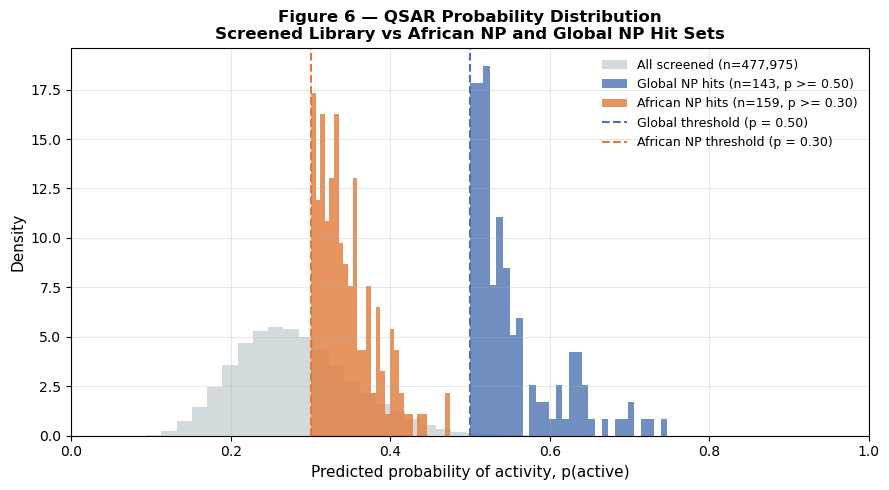

✓ Figure 6 saved


In [51]:
# ── CELL 13: Figure 6 — Probability Distribution ─────────────────────────────
 
probs_all      = np.load(DATA / "screening_probs_all.npy")
probs_global   = global_sorted['p_active'].values
probs_african  = african_sorted['p_active'].values
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(probs_all,     bins=50, alpha=0.4, color='#90A4AE', density=True,
        label=f'All screened (n={len(probs_all):,})')
ax.hist(probs_global,  bins=30, alpha=0.8, color='#4C72B0', density=True,
        label=f'Global NP hits (n={len(probs_global):,}, p >= 0.50)')
ax.hist(probs_african, bins=30, alpha=0.8, color='#E07B39', density=True,
        label=f'African NP hits (n={len(probs_african):,}, p >= 0.30)')
ax.axvline(0.50, color='#4C72B0', linestyle='--', lw=1.5, label='Global threshold (p = 0.50)')
ax.axvline(0.30, color='#E07B39', linestyle='--', lw=1.5, label='African NP threshold (p = 0.30)')
ax.set_xlabel("Predicted probability of activity, p(active)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Figure 6 — QSAR Probability Distribution\n"
             "Screened Library vs African NP and Global NP Hit Sets",
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig6_probability_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 6 saved")
 
 


Generating Figure 7 — Chemical space PCA...


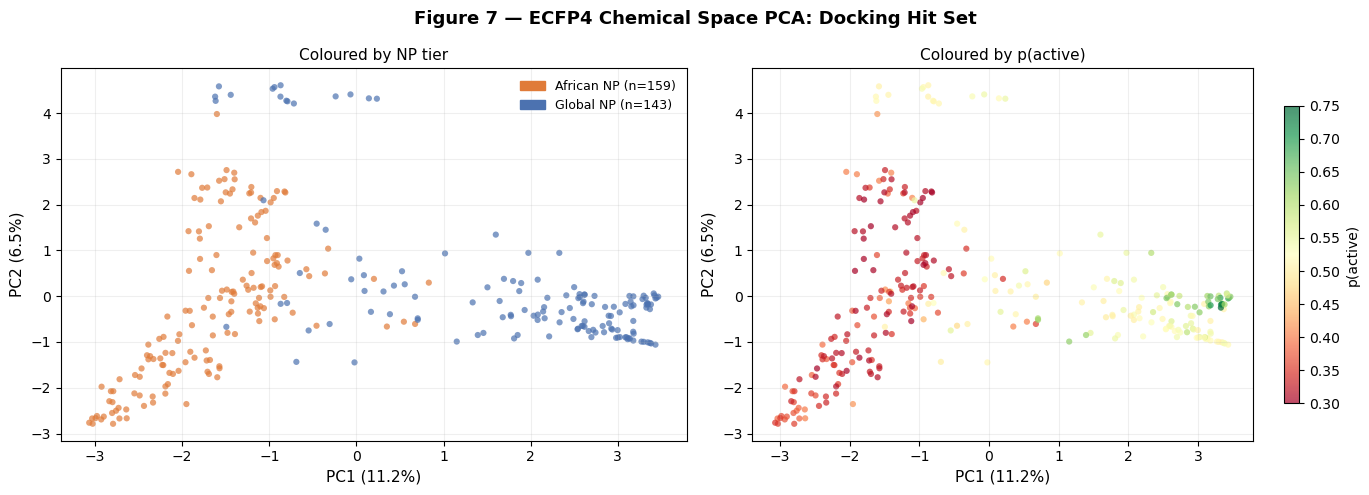

✓ Figure 7 saved


In [52]:
# ── CELL 14: Figure 7 — Chemical Space PCA ───────────────────────────────────
 
print("\nGenerating Figure 7 — Chemical space PCA...")
 
n_global_sample = min(200, len(global_sorted))
global_sample   = global_sorted.sample(n=n_global_sample, random_state=SEED)
pca_df = pd.concat([african_sorted, global_sample], ignore_index=True)
pca_df['group'] = ['African NP'] * len(african_sorted) + ['Global NP'] * n_global_sample
 
pca_fps, _  = smiles_to_morgan(pca_df['canonical_smiles'].values)
pca_model   = PCA(n_components=2, random_state=SEED)
coords      = pca_model.fit_transform(pca_fps.astype(np.float32))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7 — ECFP4 Chemical Space PCA: Docking Hit Set",
             fontsize=13, fontweight='bold')
 
# Panel A: coloured by NP tier
ax = axes[0]
colors_group = ['#E07B39' if g == 'African NP' else '#4C72B0' for g in pca_df['group']]
ax.scatter(coords[:, 0], coords[:, 1], c=colors_group, s=20, alpha=0.7, linewidths=0)
patches = [
    mpatches.Patch(color='#E07B39', label=f"African NP (n={len(african_sorted):,})"),
    mpatches.Patch(color='#4C72B0', label=f"Global NP (n={n_global_sample:,})")
]
ax.legend(handles=patches, frameon=False, fontsize=9)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("Coloured by NP tier", fontsize=11)
ax.grid(True, alpha=0.2)
 
# Panel B: coloured by p(active)
ax = axes[1]
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=pca_df['p_active'].values, cmap='RdYlGn',
                s=20, alpha=0.7, linewidths=0, vmin=0.3, vmax=0.75)
plt.colorbar(sc, ax=ax, label='p(active)', shrink=0.8)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("Coloured by p(active)", fontsize=11)
ax.grid(True, alpha=0.2)
 
plt.tight_layout()
plt.savefig(FIGURES / "fig7_chemical_space_pca.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 7 saved")
 
 

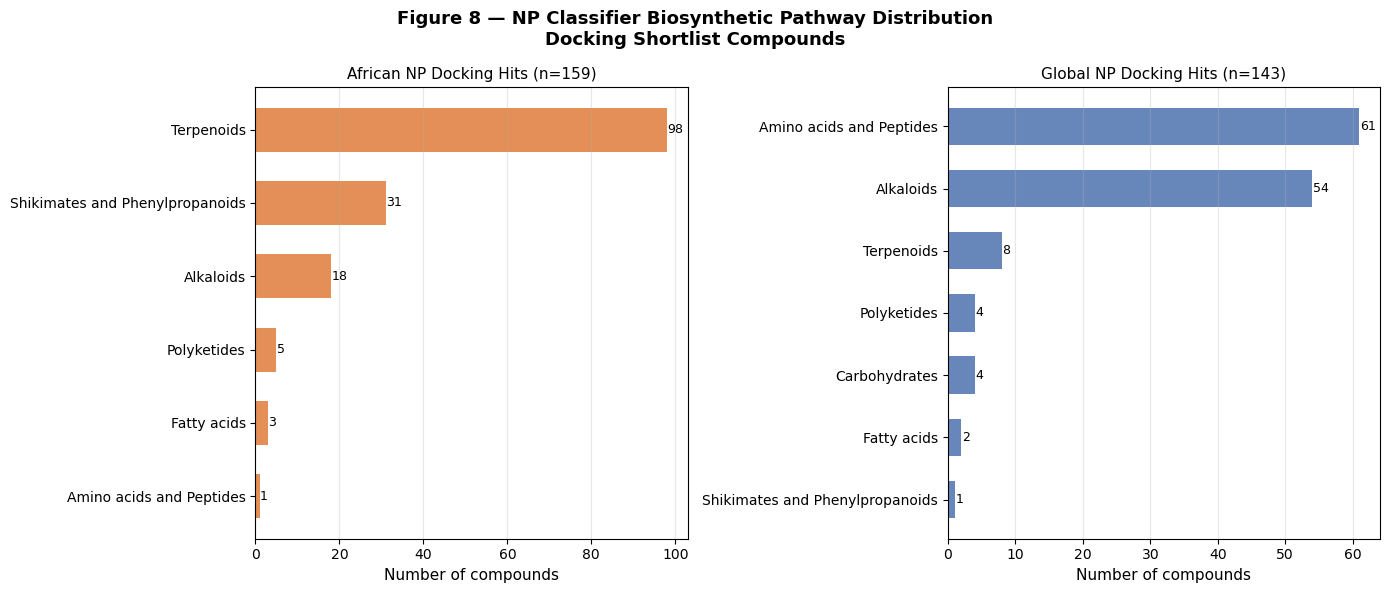

✓ Figure 8 saved


In [53]:
# ── CELL 15: Figure 8 — NP Classifier Pathway Breakdown ─────────────────────
 
def get_pathway_counts(df, col='np_classifier_pathway', top_n=10):
    if col not in df.columns:
        return pd.Series(dtype=int)
    counts = df[col].value_counts()
    return counts[counts.index.notna() & (counts.index != '')].head(top_n)
 
african_paths = get_pathway_counts(docking_set[docking_set['is_african_np'] == True])
global_paths  = get_pathway_counts(docking_set[docking_set['is_african_np'] == False])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 8 — NP Classifier Biosynthetic Pathway Distribution\n"
             "Docking Shortlist Compounds", fontsize=13, fontweight='bold')
 
for ax, (paths, title, color) in zip(axes, [
    (african_paths, f'African NP Docking Hits (n={n_african_dock})', '#E07B39'),
    (global_paths,  f'Global NP Docking Hits (n={n_global_dock})',   '#4C72B0')
]):
    if len(paths) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11)
        continue
    bars = ax.barh(paths.index[::-1], paths.values[::-1], color=color, alpha=0.85, height=0.6)
    for bar, val in zip(bars, paths.values[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_xlabel("Number of compounds", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES / "fig8_np_classifier_pathways.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 8 saved")
 

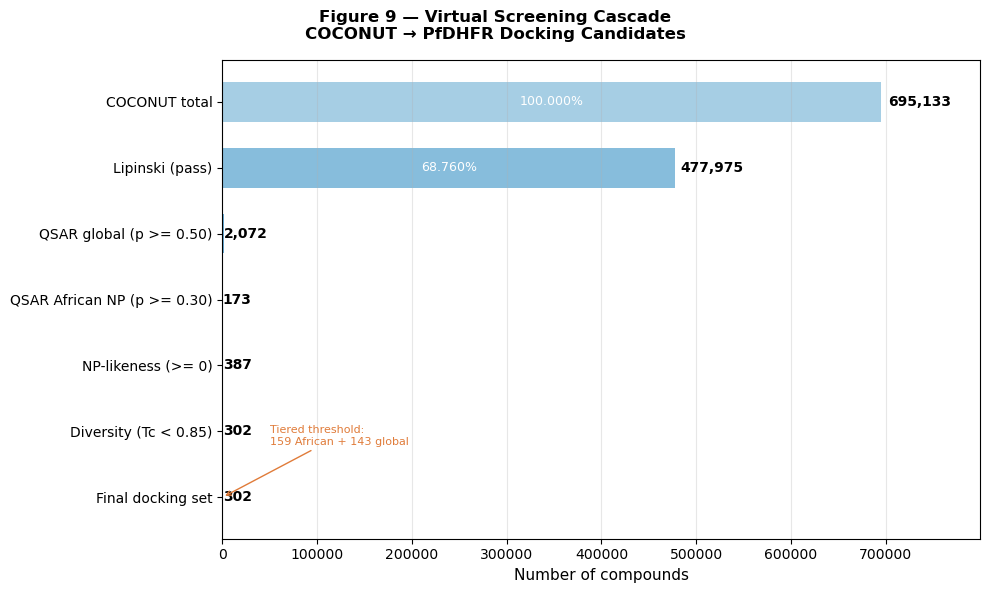

✓ Figure 9 saved


In [54]:
# ── CELL 16: Figure 9 — Screening Cascade Funnel ─────────────────────────────
 
stages = [
    ('COCONUT total',              695133),
    ('Lipinski (pass)',            477975),
    ('QSAR global (p >= 0.50)',      2072),
    ('QSAR African NP (p >= 0.30)',   173),
    ('NP-likeness (>= 0)',            387),
    ('Diversity (Tc < 0.85)',         302),
    ('Final docking set',             302),
]
 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Figure 9 — Virtual Screening Cascade\n"
             "COCONUT → PfDHFR Docking Candidates",
             fontsize=12, fontweight='bold')
 
bar_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(stages)))
for i, ((label, count), color) in enumerate(zip(stages, bar_colors)):
    ax.barh(i, count, color=color, height=0.6)
    pct = count / 695133 * 100
    ax.text(count * 1.01, i, f'{count:,}', va='center', fontsize=10, fontweight='bold')
    if pct > 0.5:
        ax.text(count * 0.5, i, f'{pct:.3f}%', va='center', ha='center',
                fontsize=9, color='white')
 
# Annotate tiered threshold
ax.annotate('Tiered threshold:\n159 African + 143 global',
            xy=(302, 6), xytext=(50000, 5.2),
            fontsize=8, color='#E07B39',
            arrowprops=dict(arrowstyle='->', color='#E07B39'))
 
ax.set_yticks(range(len(stages)))
ax.set_yticklabels([s[0] for s in stages], fontsize=10)
ax.set_xlabel("Number of compounds", fontsize=11)
ax.set_xlim(0, 695133 * 1.15)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig9_screening_cascade.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 9 saved")
 

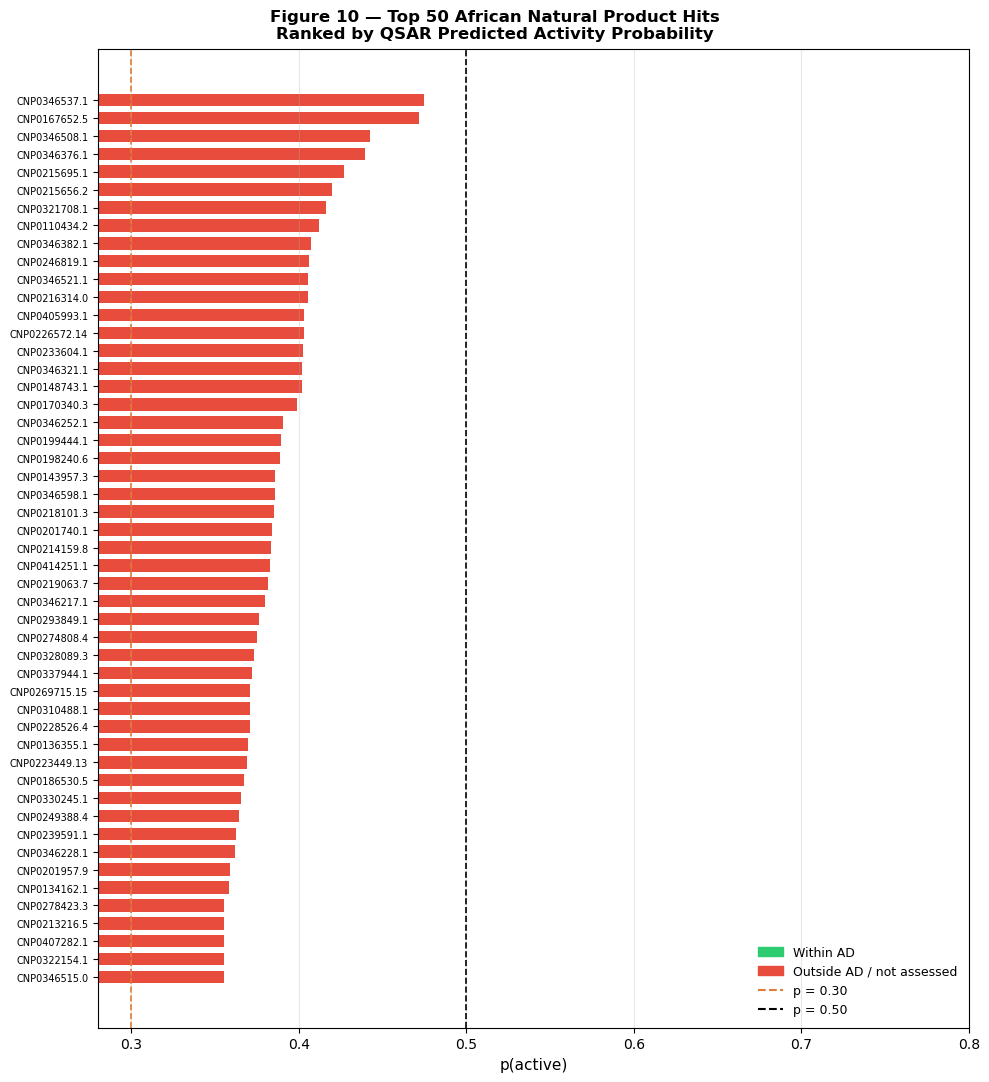

✓ Figure 10 saved


In [56]:
# ── CELL 17: Figure 10 — Top African NP Hits ─────────────────────────────────

n_top       = min(50, len(african_sorted))
top_african = african_sorted.sort_values('p_active', ascending=False).head(n_top).copy()

# African NPs bypassed AD stage — default to False (not assessed)
if 'within_ad' not in top_african.columns:
    top_african['within_ad'] = False

ad_colors = ['#2ECC71' if w else '#E74C3C'
             for w in top_african['within_ad'].fillna(False).values]

fig, ax = plt.subplots(figsize=(10, max(6, n_top * 0.22)))
fig.suptitle(f"Figure 10 — Top {n_top} African Natural Product Hits\n"
             "Ranked by QSAR Predicted Activity Probability",
             fontsize=12, fontweight='bold')

ax.barh(range(n_top)[::-1], top_african['p_active'].values, color=ad_colors, height=0.7)
ax.set_yticks(range(n_top)[::-1])
ax.set_yticklabels(top_african['identifier'].astype(str).values, fontsize=7)
ax.set_xlabel("p(active)", fontsize=11)
ax.set_xlim(0.28, 0.80)
ax.axvline(0.30, color='#E07B39', linestyle='--', lw=1.2, label='African NP threshold (0.30)')
ax.axvline(0.50, color='black',   linestyle='--', lw=1.2, label='Global threshold (0.50)')

patches = [
    mpatches.Patch(color='#2ECC71', label='Within AD'),
    mpatches.Patch(color='#E74C3C', label='Outside AD / not assessed'),
    plt.Line2D([0], [0], color='#E07B39', linestyle='--', label='p = 0.30'),
    plt.Line2D([0], [0], color='black',   linestyle='--', label='p = 0.50'),
]
ax.legend(handles=patches, frameon=False, fontsize=9, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig10_top_african_np_hits.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 10 saved")

In [58]:
# ── CELL 18: Final Summary ────────────────────────────────────────────────────

print(f"\n{'='*60}")
print("  NOTEBOOK 03 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"\n  Screening Cascade")
print(f"  COCONUT input              : {695133:>10,}")
print(f"  After Lipinski             : {477975:>10,}  (68.8%)")
print(f"  QSAR hits — global         : {2072:>10,}  (0.43%)")
print(f"  QSAR hits — African NP     : {173:>10,}  (0.036%)")
print(f"  After NP-likeness          : {387:>10,}")
print(f"  After diversity            : {302:>10,}")
print(f"\n  Final Docking Set          : {len(docking_set):>10,}")
print(f"  African NP tier            : {n_african_dock:>10,}  (p >= 0.30)")
print(f"  Global NP tier             : {n_global_dock:>10,}  (p >= 0.50)")

print(f"\n  African NP Tier Statistics")
print(f"  AD status                  : {'not assessed (relaxed threshold tier)'}")

print(f"\n  Global NP Tier Statistics")
global_in_docking = docking_set[docking_set['is_african_np'] == False]
if 'within_ad' in global_in_docking.columns:
    n_within = int(global_in_docking['within_ad'].fillna(False).sum())
    pct      = 100 * global_in_docking['within_ad'].fillna(False).mean()
    print(f"  Within AD                  : {n_within:>10,}  ({pct:.1f}%)")

if 'pred_pIC50' in docking_set.columns:
    all_wa = docking_set[docking_set['pred_pIC50'].notna()]
    if len(all_wa) > 0:
        print(f"\n  Potency Estimates (within-AD, supplementary)")
        print(f"  Compounds assessed         : {len(all_wa):>10,}")
        print(f"  Pred pIC50 mean            : {all_wa['pred_pIC50'].mean():>10.2f}")
        print(f"  Pred pIC50 std             : {all_wa['pred_pIC50'].std():>10.2f}")
        print(f"  Pred pIC50 max             : {all_wa['pred_pIC50'].max():>10.2f}")
        print(f"  Pred pIC50 min             : {all_wa['pred_pIC50'].min():>10.2f}")

print(f"\n  Files saved to {DATA}")
for fname in ['vs_hits_all_diverse.parquet', 'vs_african_np_hits.csv',
              'vs_docking_shortlist.csv',     'vs_docking_smiles.csv',
              'vs_cascade_summary.csv']:
    print(f"    {fname}")

print(f"\n  Figures saved to {FIGURES}")
for fname in ['fig6_probability_distribution.png', 'fig7_chemical_space_pca.png',
              'fig8_np_classifier_pathways.png',    'fig9_screening_cascade.png',
              'fig10_top_african_np_hits.png']:
    print(f"    {fname}")

print(f"\n  Next: notebook_04_molecular_docking.ipynb")
print(f"{'='*60}")


  NOTEBOOK 03 — FINAL SUMMARY

  Screening Cascade
  COCONUT input              :    695,133
  After Lipinski             :    477,975  (68.8%)
  QSAR hits — global         :      2,072  (0.43%)
  QSAR hits — African NP     :        173  (0.036%)
  After NP-likeness          :        387
  After diversity            :        302

  Final Docking Set          :        302
  African NP tier            :        159  (p >= 0.30)
  Global NP tier             :        143  (p >= 0.50)

  African NP Tier Statistics
  AD status                  : not assessed (relaxed threshold tier)

  Global NP Tier Statistics
  Within AD                  :        133  (93.0%)

  Potency Estimates (within-AD, supplementary)
  Compounds assessed         :        133
  Pred pIC50 mean            :       5.62
  Pred pIC50 std             :       0.36
  Pred pIC50 max             :       6.76
  Pred pIC50 min             :       4.29

  Files saved to C:\my_projects_all\portfolio_projects\Msc_project\data
    v